## Pauli Correlation Encoding to reduce qubits requirements

The goal of this project is to use Pauli Correlation Encoding to encode optimization problems into few qubits.
We will compare classical solvers with quantum solvers, for the Max-Cut problem and for the Minimal-Multi-Cut.

## What is the Pauli Encoding ?

 *Pauli Correlation Encoding*  is an approach designed to encode optimization problems into qubits with greater efficiency for quantum computation. PCE maps classical variables in optimization problems to multi-body Pauli-matrix correlations, resulting in a polynomial compression of the problem's space requirements. By employing PCE, the number of qubits needed for encoding is reduced, making it particularly advantageous for near-term quantum devices with limited qubit resources. Furthermore, it is analytically demonstrated that PCE inherently mitigates barren plateaus, offering super-polynomial resilience against this phenomenon. This built-in feature enables unprecedented performance in quantum optimization solvers.

## Requirements

Be sure you have the following installed:

* Qiskit SDK v1.0 or later, with [visualization](/docs/api/qiskit/visualization) support
* Qiskit Runtime v0.22 or later (`pip install qiskit-ibm-runtime`)


## Différents problème : 

## Max-cut : 
Le problème MaxCut est un défi d'optimisation combinatoire NP-difficile qui consiste à partitionner les sommets d'un graphe $G=(V, E)$ en deux sous-ensembles disjoints de telle sorte que la somme des poids des arêtes reliant ces deux ensembles soit maximale. Mathématiquement, on cherche à maximiser la fonction objective $\mathcal{V}(x) = \sum_{(i,j) \in E} W_{ij} (1 - x_i x_j)$, où $W_{ij}$ représente le poids de l'arête entre les sommets $i$ et $j$, et $x_i \in \{-1, 1\}$ indique l'appartenance de chaque sommet à l'une des deux partitions. Ce problème est fondamental car de nombreux défis industriels peuvent y être ramenés, mais son approximation au-delà d'un ratio de 0,941 est considérée comme calculatoirement impossible pour des algorithmes classiques en temps polynomial. L'approche par Encodage par Corrélations de Pauli (PCE) permet de s'attaquer à ce problème à grande échelle en compressant les $m$ variables de décision dans un nombre réduit de qubits $n$, offrant ainsi une voie prometteuse pour les dispositifs quantiques actuels.

## Minimal-Multi-Cut :
Le problème du Minimum Multi-Cut est une généralisation du problème de coupe classique qui intervient dans l'optimisation de réseaux et le partitionnement de données. Contrairement au MaxCut qui sépare les sommets en seulement deux groupes, le Multi-Cut cherche à trouver l'ensemble minimal d'arêtes dont la suppression déconnecte plusieurs paires de sommets spécifiques (sources et puits) définies à l'avance. Ce problème est également NP-difficile et possède des applications cruciales dans la segmentation d'images complexes, la gestion de clusters de serveurs et la bio-informatique. Bien que l'article de Sciorilli et al. se concentre principalement sur le MaxCut pondéré, leur approche par Encodage par Corrélations de Pauli (PCE) est théoriquement extensible à tout problème d'optimisation binaire quadratique non contraint (QUBO), permettant ainsi de traiter des instances de Multi-Cut de grande taille sur des dispositifs quantiques à faible nombre de qubits.

## Choix du probème à résoudre :

Choisissez parmi "Max-cut" et "Minimal-Multi-Cut" le probème que vous souhaitez résoudre.

In [1]:
problem = "Max-Cut"
#problem = "Minimal-Multi-Cut"

## Création de l'instance de résolution du problème
- soit on importe un graphe/arbre de son choix
- soit on utilise le générateur d'instance pour créer un graphe/arbre

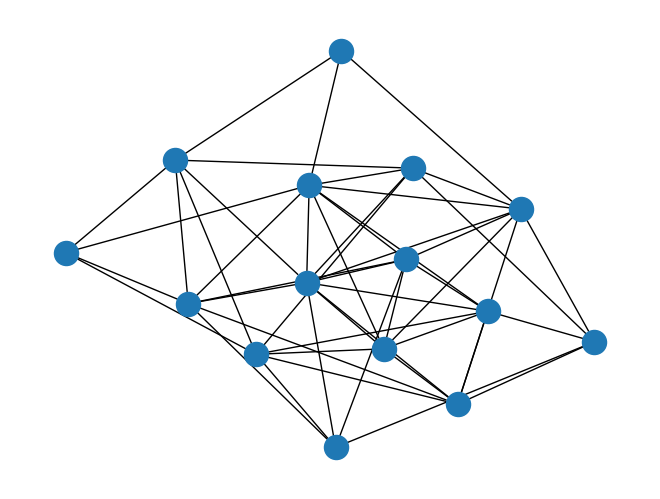

In [2]:
from instance_generator import instance_creation
num_nodes = 15

instance = instance_creation(num_nodes, problem)

## Résolution classique : 

In [3]:
from classical_solvers import classical_solver

classical_cut_size, classical_partition = classical_solver(instance, problem)

Cut size: 35
Partition 1: {0, 5, 6, 8, 10, 11, 14}
Partition 2: {1, 2, 3, 4, 7, 9, 12, 13}


## Encodage de Pauli des noeuds du graphe : 

In [4]:
from variables_encoding import variables_encoding

num_qubits = 4

pce_groups = variables_encoding(num_nodes, num_qubits)

List X: [0, 3, 6, 9, 12]
List Y: [1, 4, 7, 10, 13]
List Z: [2, 5, 8, 11, 14]
[SparsePauliOp(['IIXX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIIX'],
              coeffs=[1.+0.j]), SparsePauliOp(['IXXI'],
              coeffs=[1.+0.j]), SparsePauliOp(['XIXI'],
              coeffs=[1.+0.j])]
[SparsePauliOp(['IIYY'],
              coeffs=[1.+0.j]), SparsePauliOp(['IYIY'],
              coeffs=[1.+0.j]), SparsePauliOp(['YIIY'],
              coeffs=[1.+0.j]), SparsePauliOp(['IYYI'],
              coeffs=[1.+0.j]), SparsePauliOp(['YIYI'],
              coeffs=[1.+0.j])]
[SparsePauliOp(['IIZZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['IZIZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZIIZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['IZZI'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZIZI'],
              coeffs=[1.+0.j])]


## Résolution quantique :

In [5]:
from quantum_solvers import solve_maxcut_pce
from utils import calc_cut_size
import networkx as nx

instance = nx.convert_node_labels_to_integers(instance)
n_nodes = len(instance.nodes())

results = solve_maxcut_pce( num_qubits=4, pce_groups=pce_groups, instance=instance, max_iter=150)

# Affichage des résultats 
print(f"Partition 0 : {results['par0']}")
print(f"Partition 1 : {results['par1']}")

# Calcul de la taille du cut final
cut_size = calc_cut_size(instance, results['par0'], results['par1'])
print(f"Taille du Cut : {cut_size}")

QiskitError: 'Invalid input data for Pauli.'

## Post Processing par bit-swap :

In [ ]:
from utils import bit_swap

best_cut, best_bits = bit_swap(results, instance)
print(f"Best cut size after bit swap: {best_cut}")
print(f"Best bit configuration: {best_bits}")